In [218]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [219]:
df = pd.read_csv("gacco_cleaned.csv")
df.head()

,Time,Tp,Cl,pH,Redox,Leit,Trueb,Cl_2,Fm,Fm_2,EVENT
0,2016-08-04 00:00:00,6.5,0.17,8.41,747.0,211.0,0.017,0.109,1469.0,805.0,False
1,2016-08-04 00:01:00,6.5,0.17,8.41,748.0,211.0,0.018,0.108,1435.0,811.0,False
2,2016-08-04 00:02:00,6.5,0.17,8.41,748.0,211.0,0.017,0.109,1423.0,806.0,False
3,2016-08-04 00:03:00,6.5,0.17,8.41,747.0,211.0,0.017,0.109,1425.0,814.0,False
4,2016-08-04 00:04:00,6.5,0.17,8.41,747.0,211.0,0.017,0.109,1445.0,809.0,False


In [220]:
df.shape

(125280, 11)

In [221]:
# total time
time_series = pd.to_datetime(df['Time'])
time_series.iloc[-1].date() - time_series.iloc[0].date()

datetime.timedelta(days=86)

In [222]:
# total anomalies
df['EVENT'].value_counts()

EVENT
False    123631
True       1649
Name: count, dtype: int64

In [223]:
# anomaly percentage
anomaly_percentage = df['EVENT'].value_counts(normalize=True) * 100
anomaly_percentage

EVENT
False    98.683748
True      1.316252
Name: proportion, dtype: float64

In [224]:
# anomalies per day
df['Time'] = pd.to_datetime(df['Time'])
anomalies_per_day = df[df['EVENT'] == 1].groupby(df['Time'].dt.date).size()
anomalies_per_day.shape, anomalies_per_day

((23,),
 Time
 2016-08-14     35
 2016-08-15     56
 2016-08-16     53
 2016-08-31     21
 2016-09-01     42
 2016-09-02     21
 2016-09-03     21
 2016-09-07    198
 2016-09-14    253
 2016-09-16     10
 2016-09-17     44
 2016-09-18    132
 2016-09-19    110
 2016-09-22    157
 2016-09-24     46
 2016-09-25    115
 2016-09-26    138
 2016-09-27     23
 2016-10-06     58
 2016-10-07     29
 2016-10-08     29
 2016-10-09     29
 2016-10-10     29
 dtype: int64)

### Group By

In [225]:
# ensure Time is datetime before time-based grouping
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')

group_freq = '20min'  # Grouping frequency (5 minutes)

df_grouped = (
    df.dropna(subset=['Time'])
      .set_index('Time')
      .groupby(pd.Grouper(freq=group_freq))
      .mean(numeric_only=True)
 )

df_grouped['EVENT'] = (
    df.dropna(subset=['Time'])
      .set_index('Time')
      .groupby(pd.Grouper(freq=group_freq))['EVENT']
      .max()
 )

df_grouped.head()

,Tp,Cl,pH,Redox,Leit,Trueb,Cl_2,Fm,Fm_2,EVENT
Time,,,,,,,,,,
2016-08-04 00:00:00,6.500,0.1680,8.3995,747.25,209.2,0.01735,0.10810,1457.00,806.90,False
2016-08-04 00:20:00,6.505,0.1670,8.3820,747.50,207.2,0.02215,0.10730,1422.40,806.65,False
2016-08-04 00:40:00,6.510,0.1700,8.3755,747.55,207.0,0.01850,0.10915,1489.75,807.45,False
2016-08-04 01:00:00,6.500,0.1685,8.3605,747.95,207.0,0.01725,0.11070,1475.20,804.35,False
2016-08-04 01:20:00,6.500,0.1595,8.3270,748.80,207.0,0.01925,0.11300,1488.65,802.45,False


### Analysis

In [226]:
DAYS = 7
# TIME_STEPS_PER_DAY = 1440
# TIME_STEPS_PER_DAY = 144
TIME_STEPS_PER_DAY = 72

In [227]:
# for col in df.select_dtypes(include='number').columns:
#     plt.figure(figsize=(16, 8))
#     plt.plot(df[col][:DAYS * TIME_STEPS_PER_DAY].values)
#     # day separators
#     for j in range(0, DAYS * TIME_STEPS_PER_DAY, TIME_STEPS_PER_DAY):
#             plt.axvline(x=j, color='r', linestyle='--', alpha=0.5)
#     for j in df.index[:DAYS * TIME_STEPS_PER_DAY][df['EVENT'].iloc[:DAYS * TIME_STEPS_PER_DAY].to_numpy()]:
#         plt.axvline(x=j, color='r', linestyle='-', alpha=0.1)
#     plt.title(col)
#     plt.xlabel('Time')
#     plt.ylabel('Value')
#     plt.show()
    

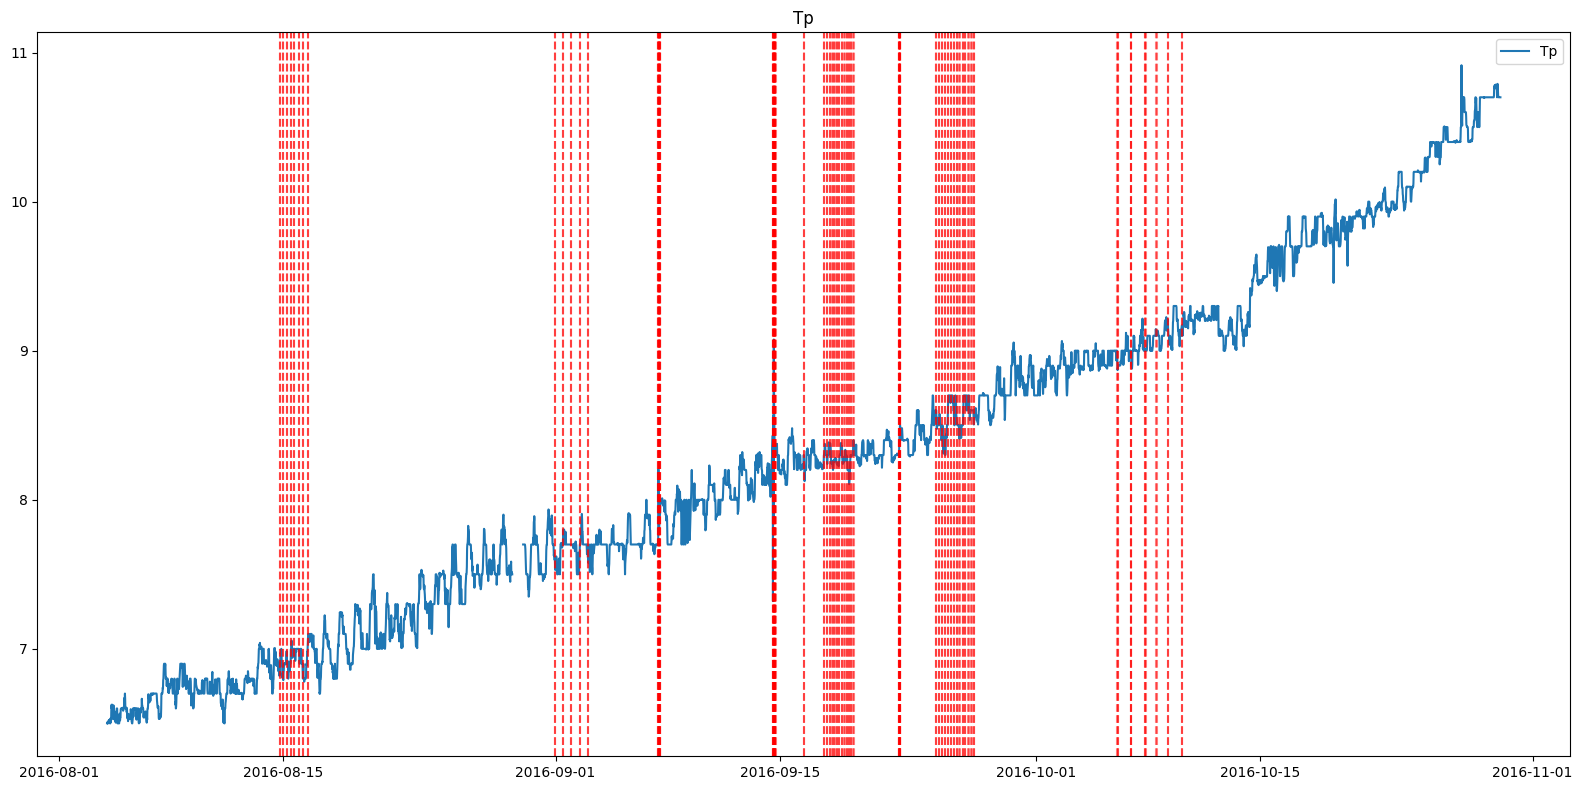

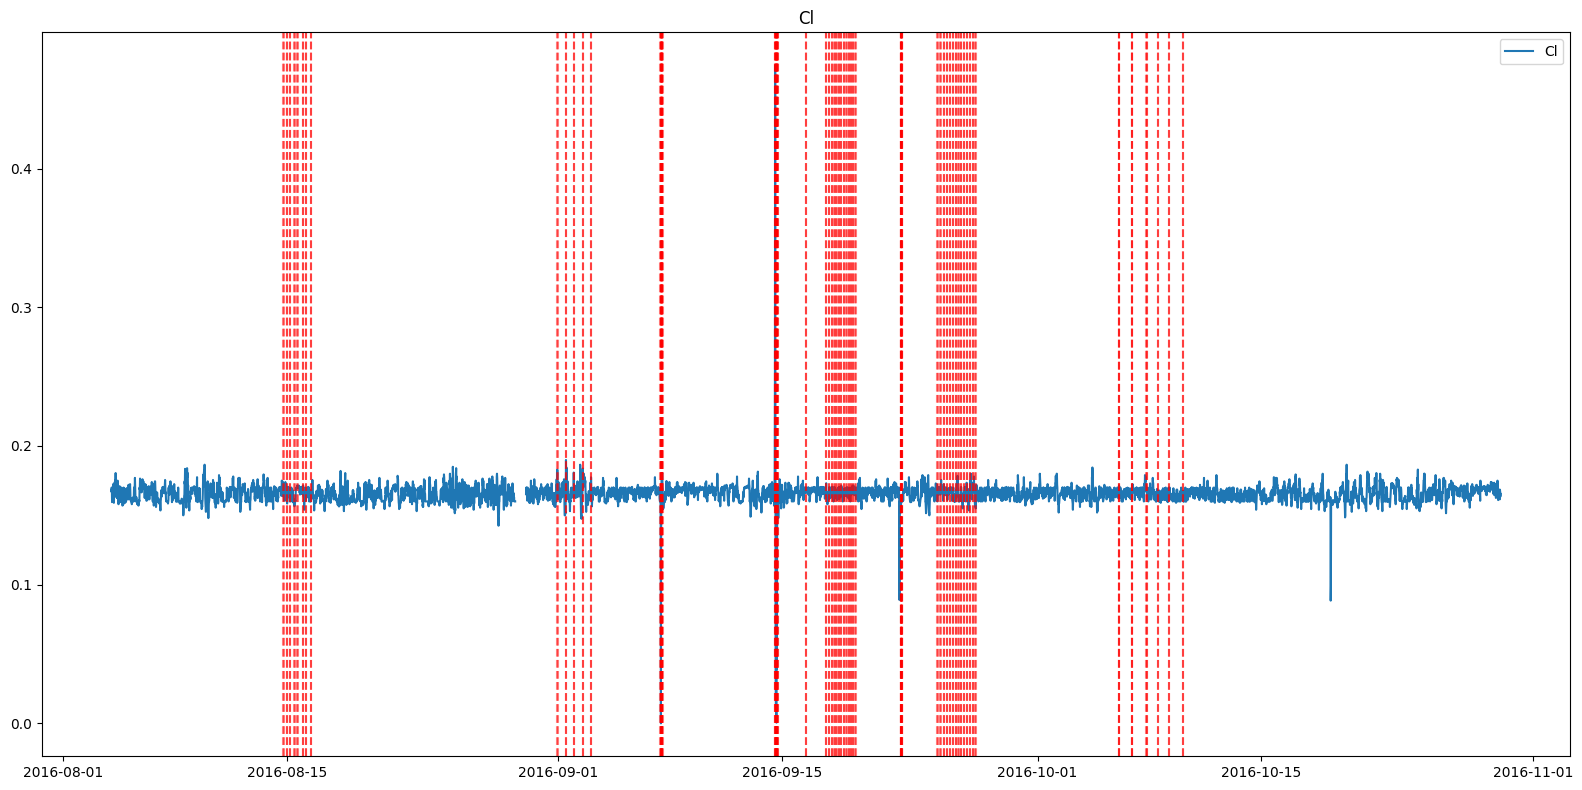

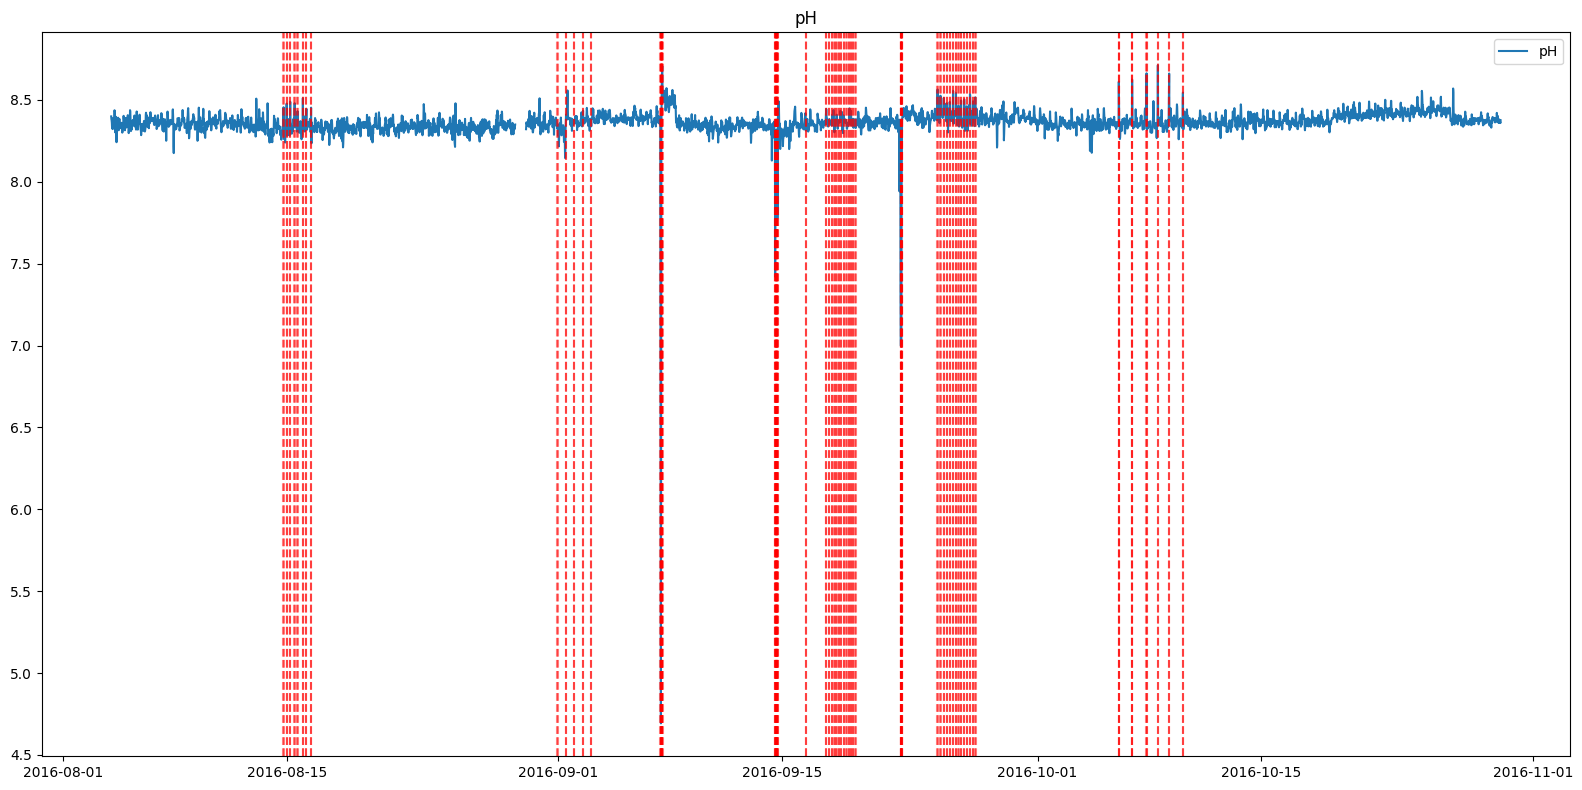

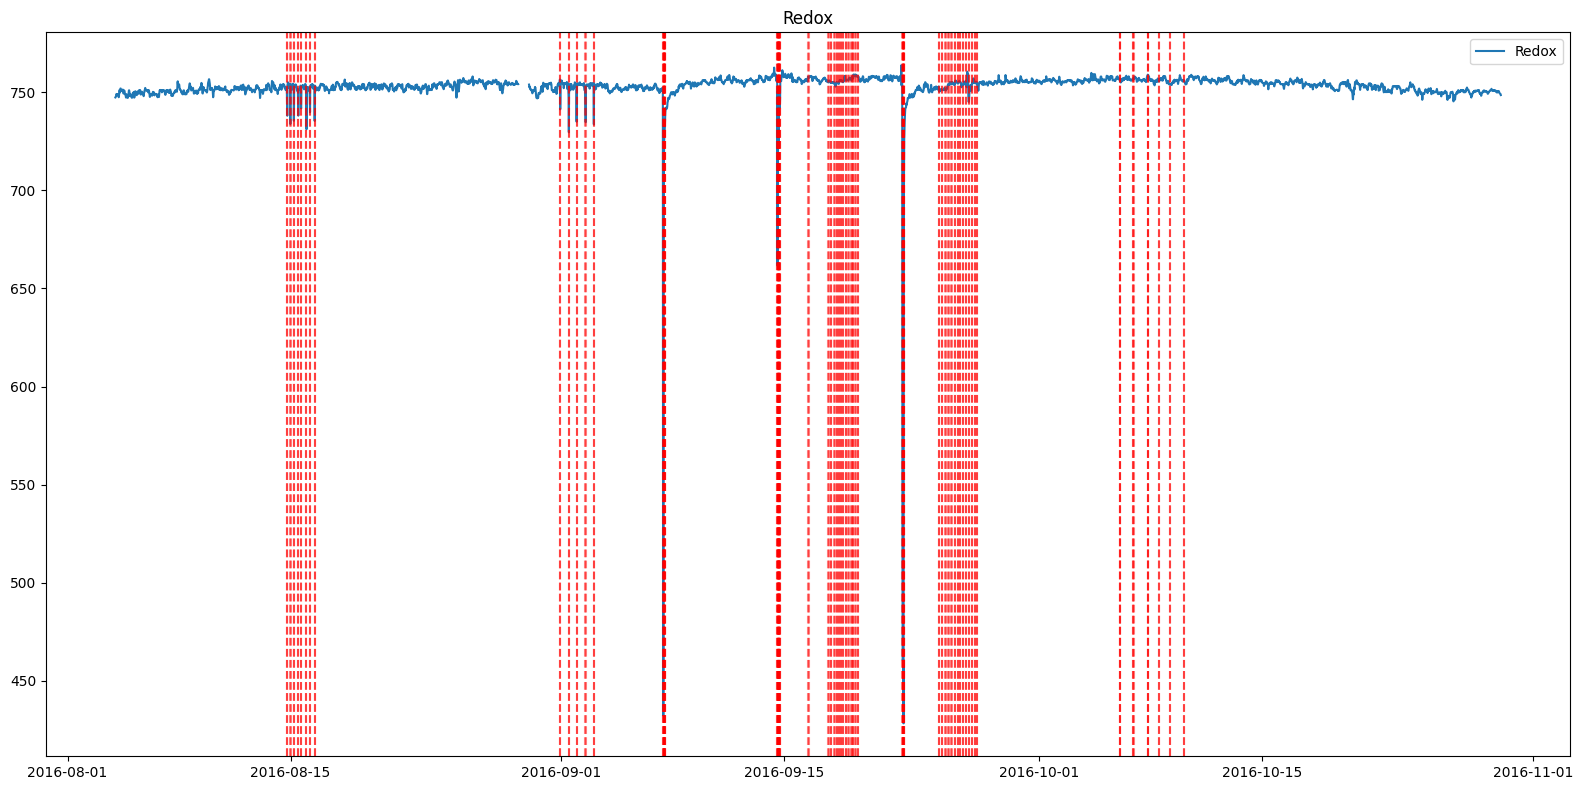

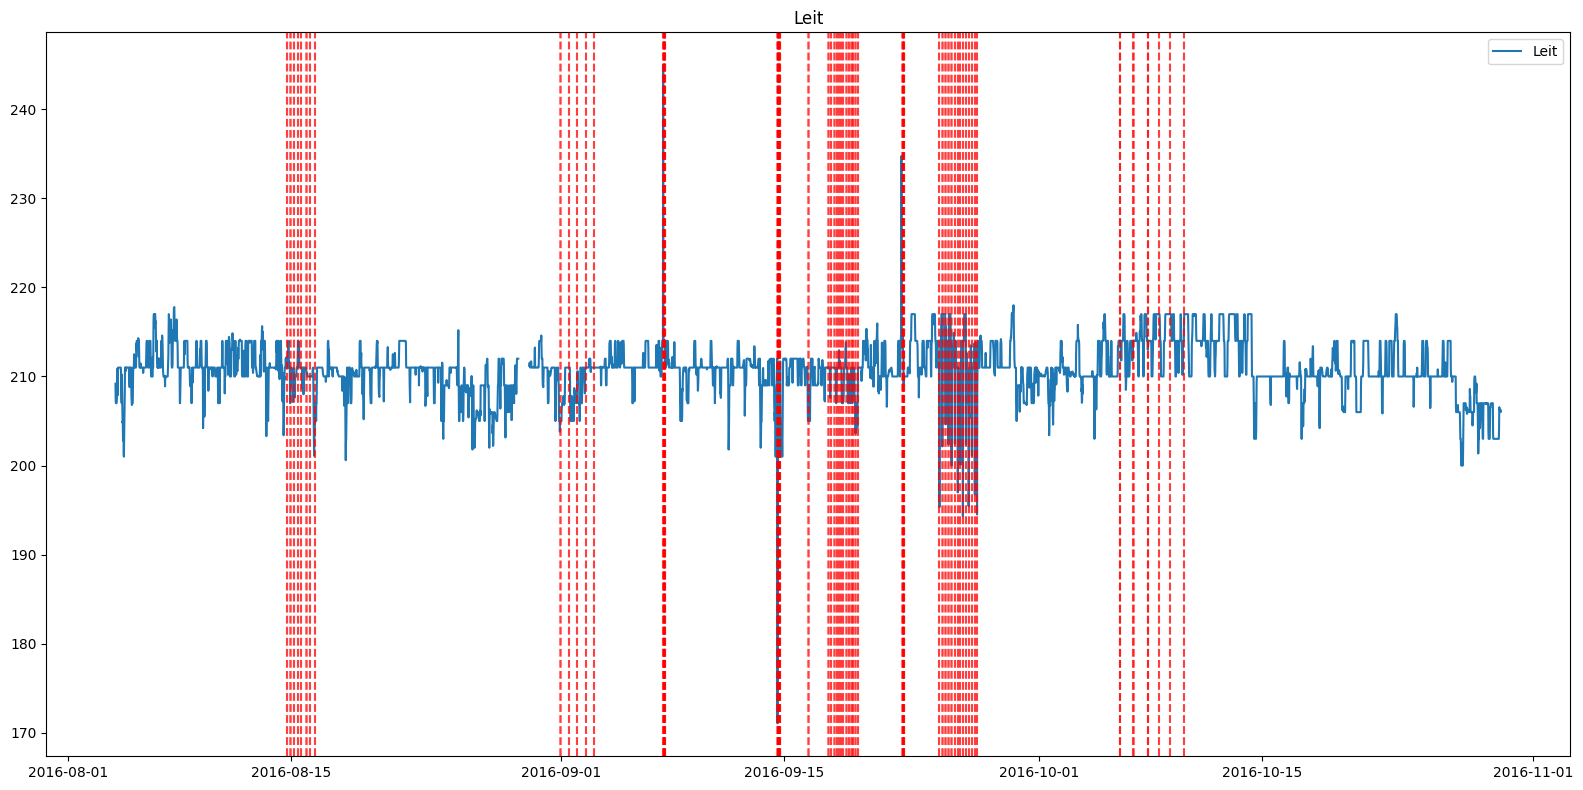

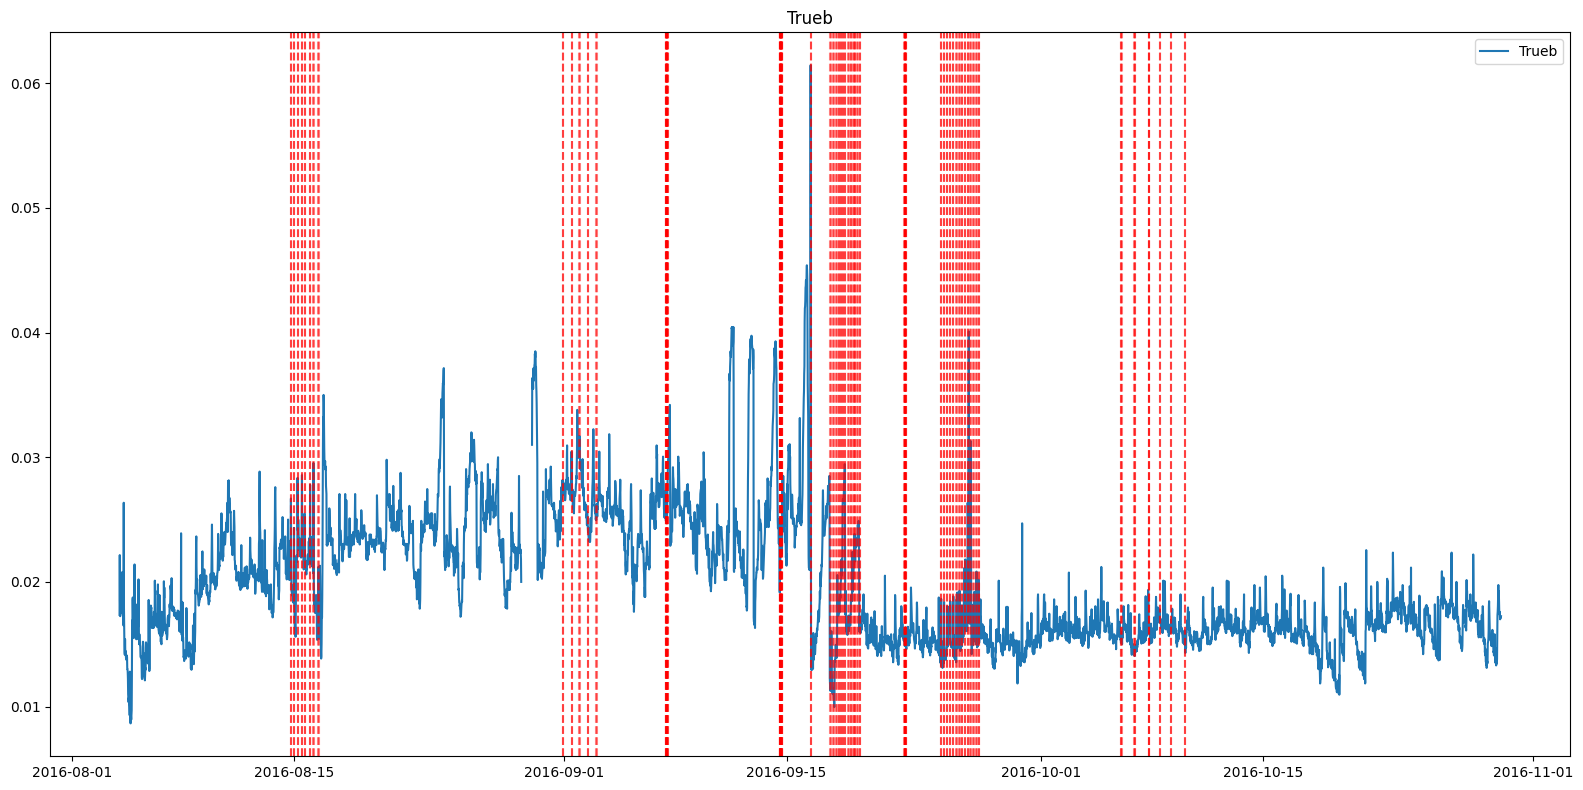

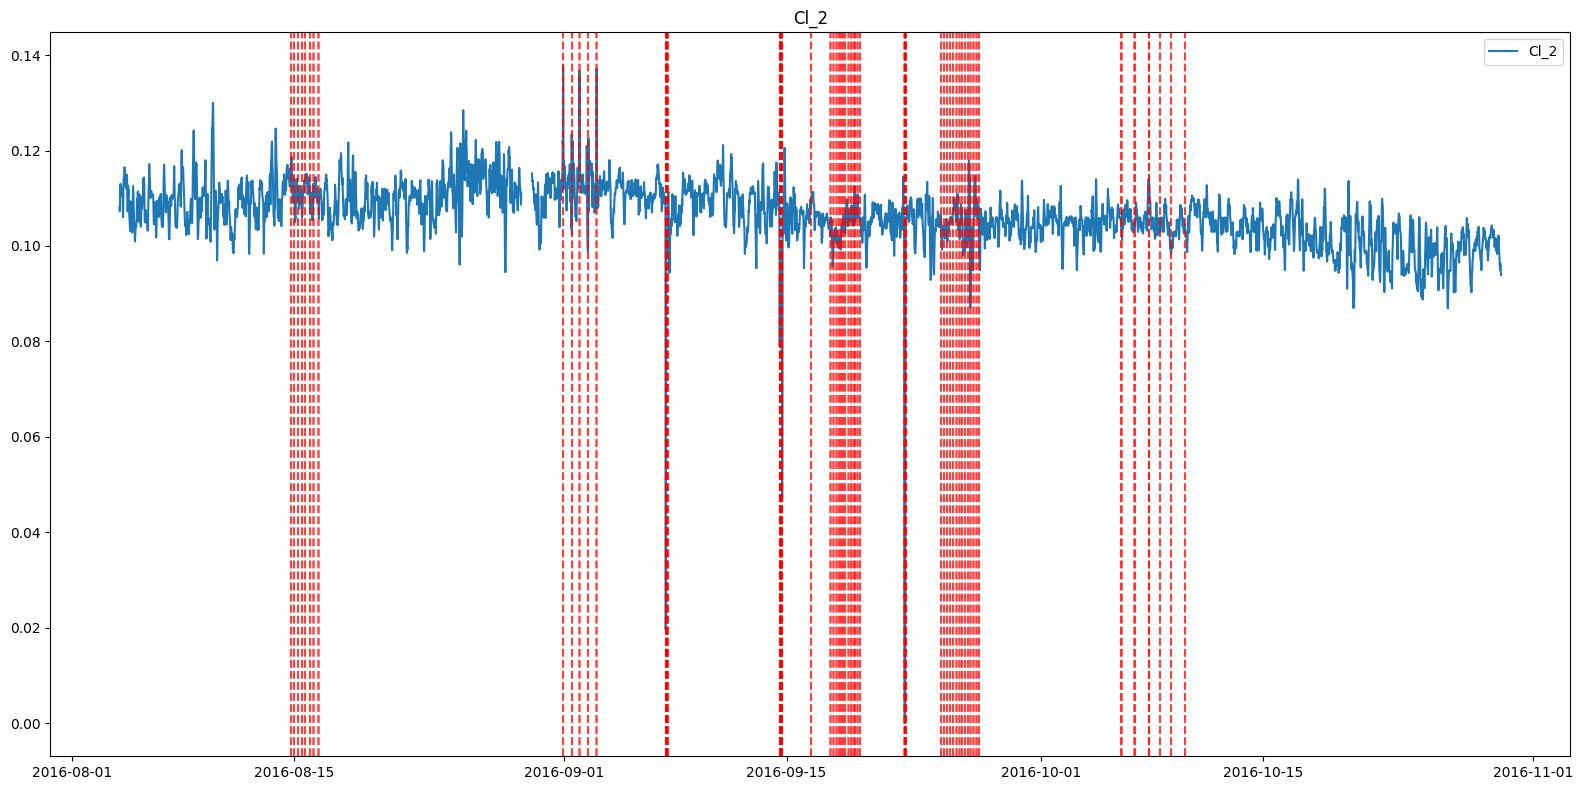

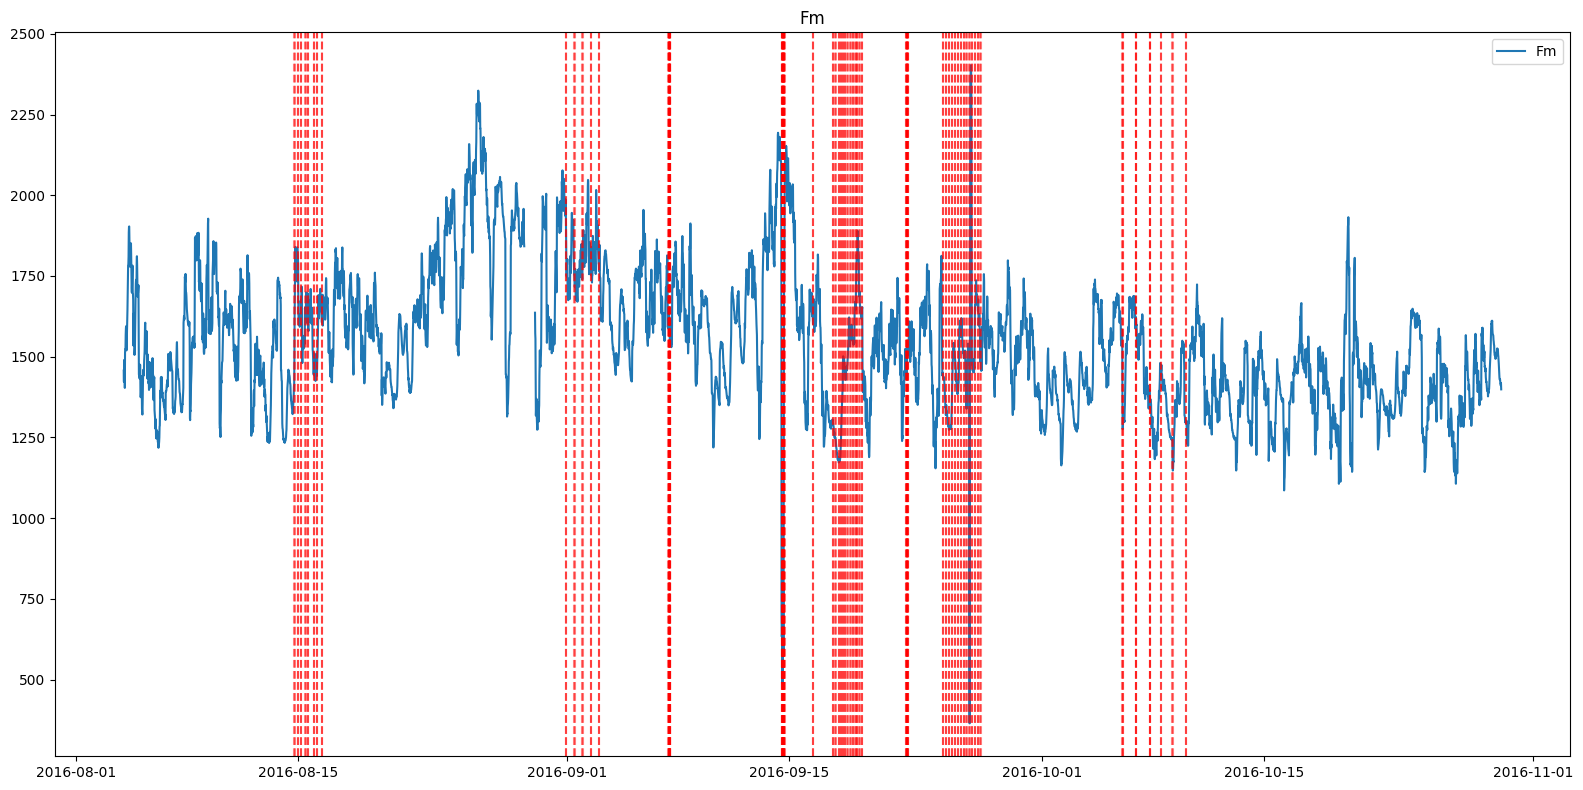

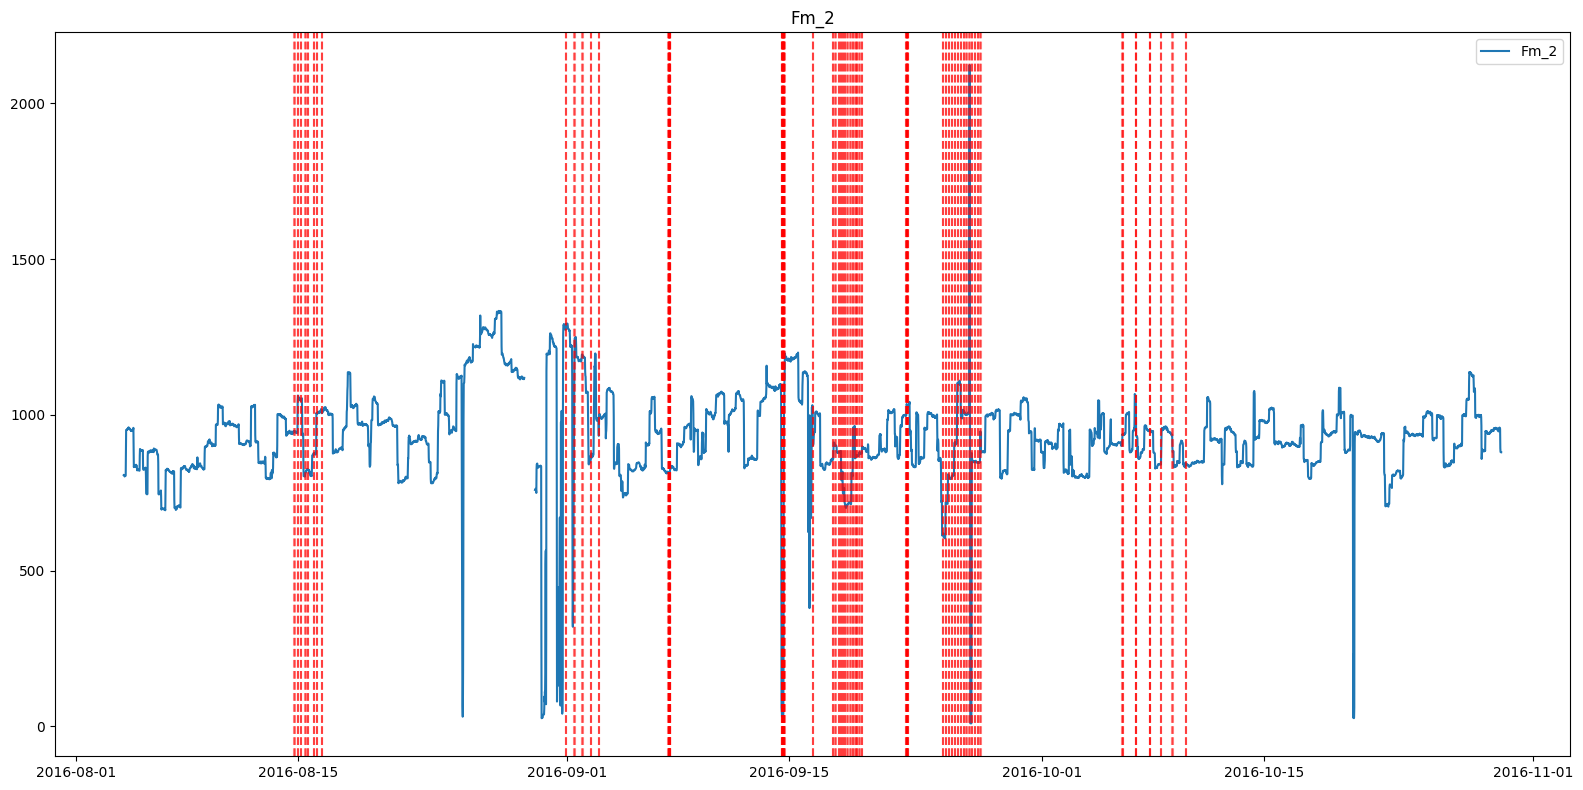

In [228]:
anomaly_times = df_grouped.index[df_grouped['EVENT'] == 1]

for col in df_grouped.select_dtypes(include='number').columns:
    if col == 'EVENT':
        continue

    plt.figure(figsize=(16, 8))
    plt.plot(df_grouped.index, df_grouped[col].values, label=col)
    for j in anomaly_times:
        plt.axvline(x=j, color='r', linestyle='--', alpha=0.5)
    plt.title(col)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [229]:
df = df_grouped.copy()

### Only using data of 25 days

In [230]:
df = df.iloc[:DAYS*TIME_STEPS_PER_DAY]
df_raw = df.copy()
df.head()

,Tp,Cl,pH,Redox,Leit,Trueb,Cl_2,Fm,Fm_2,EVENT
Time,,,,,,,,,,
2016-08-04 00:00:00,6.500,0.1680,8.3995,747.25,209.2,0.01735,0.10810,1457.00,806.90,False
2016-08-04 00:20:00,6.505,0.1670,8.3820,747.50,207.2,0.02215,0.10730,1422.40,806.65,False
2016-08-04 00:40:00,6.510,0.1700,8.3755,747.55,207.0,0.01850,0.10915,1489.75,807.45,False
2016-08-04 01:00:00,6.500,0.1685,8.3605,747.95,207.0,0.01725,0.11070,1475.20,804.35,False
2016-08-04 01:20:00,6.500,0.1595,8.3270,748.80,207.0,0.01925,0.11300,1488.65,802.45,False


In [231]:
columns_to_drop = ['EVENT']
df.drop(columns=columns_to_drop, inplace=True)

In [232]:
scaler = StandardScaler()
df[df.columns] = scaler.fit_transform(df)
df.head()

,Tp,Cl,pH,Redox,Leit,Trueb,Cl_2,Fm,Fm_2
Time,,,,,,,,,
2016-08-04 00:00:00,-1.633718,0.480298,1.195495,-1.926170,-0.886851,-0.053041,-0.201493,-0.553781,-0.659872
2016-08-04 00:20:00,-1.586358,0.304247,0.692321,-1.770923,-1.737377,1.327441,-0.376526,-0.766582,-0.662860
2016-08-04 00:40:00,-1.538999,0.832399,0.505428,-1.739873,-1.822429,0.277700,0.028239,-0.352358,-0.653299
2016-08-04 01:00:00,-1.633718,0.568323,0.074135,-1.491478,-1.822429,-0.081801,0.367367,-0.441845,-0.690348
2016-08-04 01:20:00,-1.633718,-1.016135,-0.889084,-0.963639,-1.822429,0.493400,0.870588,-0.359123,-0.713056


### Smoothing using rolling mean

In [233]:
# # make each numeric column smooth by rolling mean
# numeric_cols = df.select_dtypes(include='number').columns
# df[numeric_cols] = df[numeric_cols].rolling(window=5, min_periods=1).mean()

# for col in ['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws']:
#     plt.figure(figsize=(12, 4))
#     plt.plot(df[col][:10000])
#     plt.title(f"{col} over time (smoothed)")

In [234]:
import math

SPLIT_RATIO = 0.7
TOTAL_POINTS = len(df)
PERIOD = DAYS
TRAIN_DAYS = math.ceil(PERIOD * SPLIT_RATIO)
TEST_DAYS = PERIOD - TRAIN_DAYS
TIME = TOTAL_POINTS // PERIOD
FEATURES = len(df.columns)
print(f"Tensor dimensions: {PERIOD} x {TIME} x {FEATURES}")
print(f"Train days: {TRAIN_DAYS}, Test days: {TEST_DAYS}")

Tensor dimensions: 7 x 72 x 9
Train days: 5, Test days: 2


In [235]:
# data = df[['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws']][:PERIOD*TIME].values
# data = df[['DEWP', 'TEMP', 'PRES', 'Iws']][:PERIOD*TIME].values
data = df[:PERIOD*TIME].values
tensor = data.reshape(PERIOD, TIME, FEATURES)
tensor.shape

(7, 72, 9)

In [236]:
train_tensor = tensor[:TRAIN_DAYS, :, :]
test_tensor = tensor[TRAIN_DAYS:TRAIN_DAYS+TEST_DAYS, :, :]
print(f"Train tensor shape: {train_tensor.shape}")
print(f"Test tensor shape: {test_tensor.shape}")

Train tensor shape: (5, 72, 9)
Test tensor shape: (2, 72, 9)


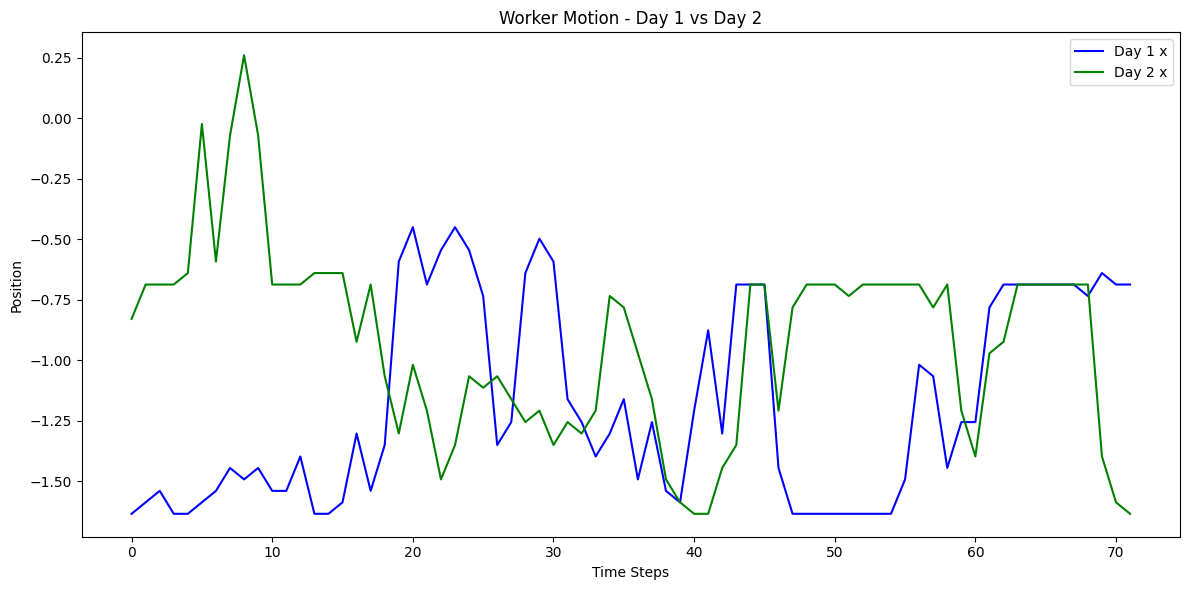

In [237]:
train_day_1 = tensor[0, :, :]
train_day_2 = tensor[1, :, :]

# day 1,3 merged
plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Day 1 y', color='blue')
plt.plot(train_day_2[:, 0], label='Day 2 x', color='green')
# plt.plot(train_day_2[:, 1], label='Day 2 y', color='green')
plt.title('Worker Motion - Day 1 vs Day 2')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor Decomposition

In [238]:
from tensorly.decomposition import parafac

R = 2
weights, factors = parafac(train_tensor, rank=R, normalize_factors=True)

day_factors, time_factors, feature_factors = factors
print(f"Day factors shape: {day_factors.shape}")
print(f"Time factors shape: {time_factors.shape}")
print(f"Feature factors shape: {feature_factors.shape}")

Day factors shape: (5, 2)
Time factors shape: (72, 2)
Feature factors shape: (9, 2)


In [239]:
from tensorly import cp_to_tensor

# Reconstruct the tensor
reconstructed_tensor = cp_to_tensor((weights, factors))

# Or without weights (if normalize_factors=True, weights contain the norms)
# reconstructed_tensor = cp_to_tensor(factors)  # this ignores weights

print(f"Original tensor shape: {train_tensor.shape}")
print(f"Reconstructed tensor shape: {reconstructed_tensor.shape}")

Original tensor shape: (5, 72, 9)
Reconstructed tensor shape: (5, 72, 9)


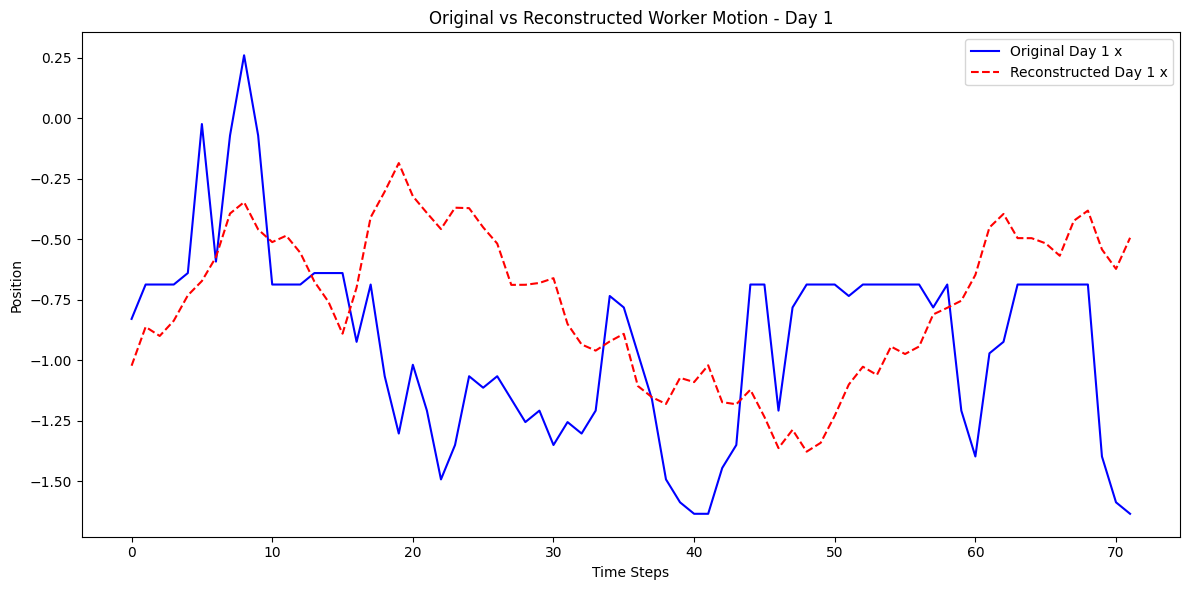

In [240]:
train_day_1 = train_tensor[1, :, :]
train_day_1_reconstructed = reconstructed_tensor[1, :, :]

plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Original Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Original Day 1 y', color='blue')
plt.plot(train_day_1_reconstructed[:, 0], label='Reconstructed Day 1 x', color='red', linestyle='dashed')
# plt.plot(train_day_1_reconstructed[:, 1], label='Reconstructed Day 1 y', color='red', linestyle='dashed')
plt.title('Original vs Reconstructed Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor AR

In [241]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.statespace.sarimax import SARIMAX

forecast_day_factors = np.zeros((TEST_DAYS, R))
for r in range(R):
    series = day_factors[:, r]
    model = AutoReg(series, lags=1, old_names=False)
    # model = AutoReg(series, lags=7, old_names=False)
    # model = SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,1,24))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=TEST_DAYS)
    forecast_day_factors[:, r] = forecast

# Reconstruct forecast tensor
forecast_tensor = np.zeros((TEST_DAYS, TIME, FEATURES))
for i in range(TEST_DAYS):
    for r in range(R):
        forecast_tensor[i, :, :] += weights[r] * np.outer(forecast_day_factors[i, r] * time_factors[:, r], feature_factors[:, r])

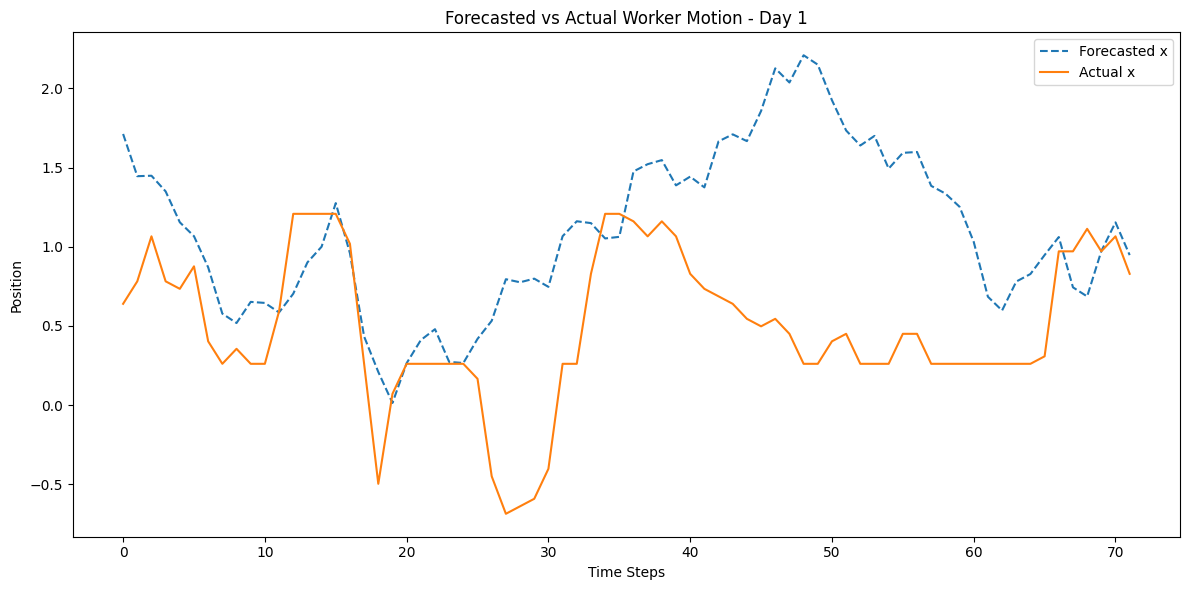

In [242]:
forecasted_day_1 = forecast_tensor[0, :, :]

forecasted_day_1_x = forecasted_day_1[:, 0]
forecasted_day_1_y = forecasted_day_1[:, 1]

test_day_1 = tensor[TRAIN_DAYS, :, :]
real_of_forecast_day_1_x = test_day_1[:, 0]
real_of_forecast_day_1_y = test_day_1[:, 1]

# merge forecast and actual for day 1
plt.figure(figsize=(12, 6))
plt.plot(forecasted_day_1_x, label='Forecasted x', linestyle='--')
# plt.plot(forecasted_day_1_y, label='Forecasted y', linestyle='--')
# plt.plot(forecasted_day_1_x, label='Forecasted x')
# plt.plot(forecasted_day_1_y, label='Forecasted y')
plt.plot(real_of_forecast_day_1_x, label='Actual x')
# plt.plot(real_of_forecast_day_1_y, label='Actual y')
plt.title('Forecasted vs Actual Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

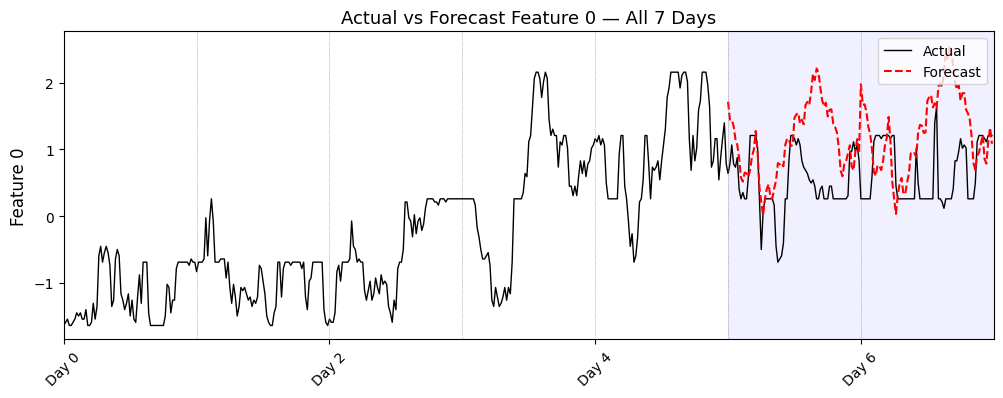

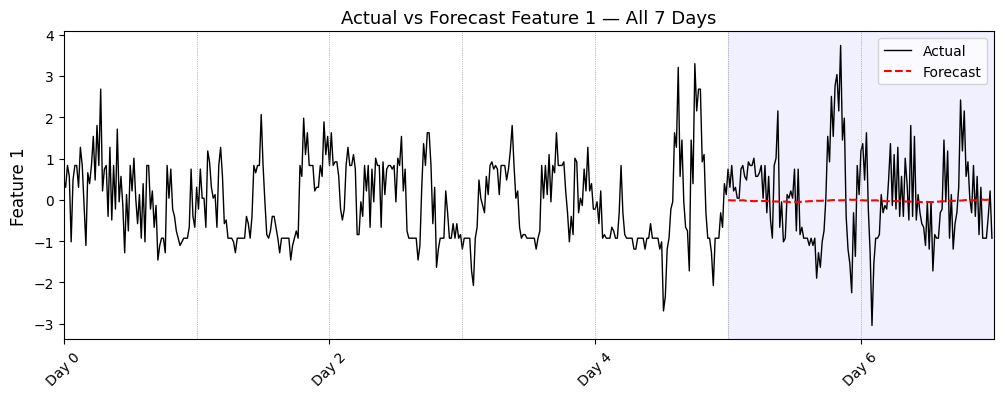

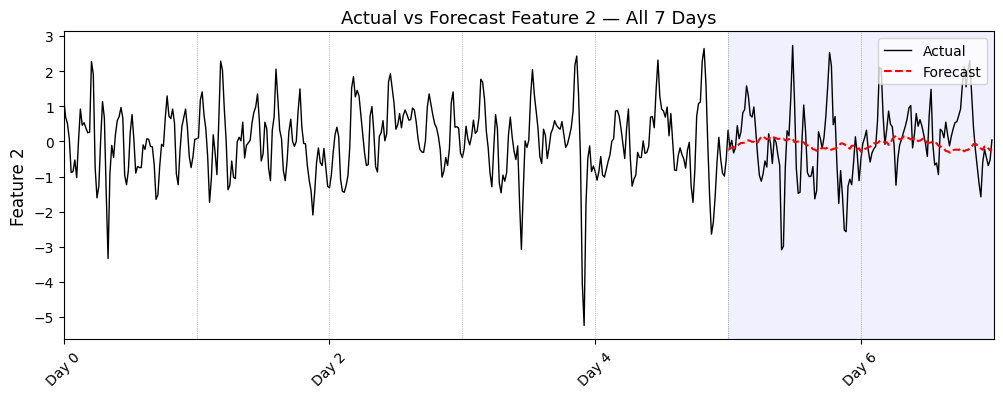

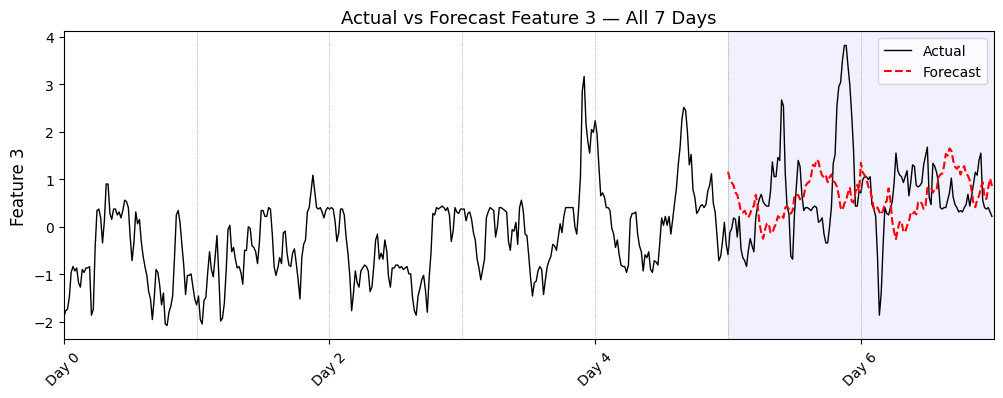

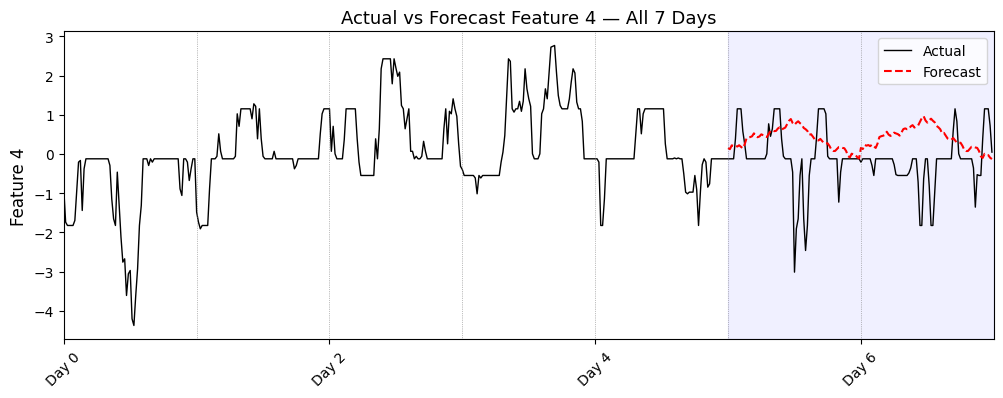

In [243]:
# Flatten full tensor and forecast tensor into time series
full_series = tensor.reshape(-1, FEATURES)
# full_series = df_raw[['Temp', 'dummy']][:PERIOD*TIME].values.reshape(-1, FEATURES) 
forecast_series = forecast_tensor.reshape(-1, FEATURES)

T = PERIOD * TIME
x = np.arange(T)
forecast_start = TRAIN_DAYS * TIME
x_forecast = np.arange(forecast_start, forecast_start + TEST_DAYS * TIME)

for i in range(5):
    plt.figure(figsize=(12, 4))
    plt.plot(x, full_series[:, i], 'k-', lw=1, label='Actual')
    plt.plot(x_forecast, forecast_series[:, i], 'r--', lw=1.5, label='Forecast')
    for d in range(1, PERIOD + 1):
        plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
    plt.xticks(np.arange(0, T + 1, 2 * TIME),
               [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
    plt.xlim(0, T)
    plt.ylabel(f'Feature {i}', fontsize=12)
    plt.title(f'Actual vs Forecast Feature {i} — All {PERIOD} Days', fontsize=13)
    plt.legend(loc='upper right')

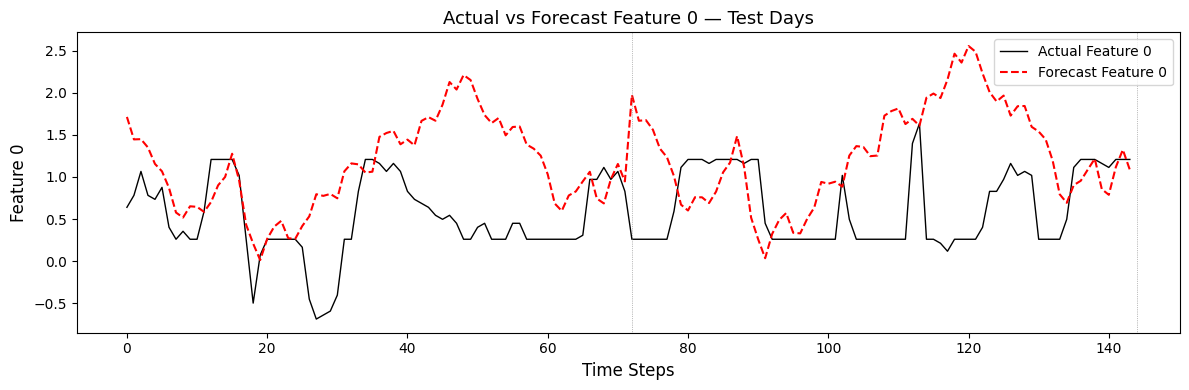

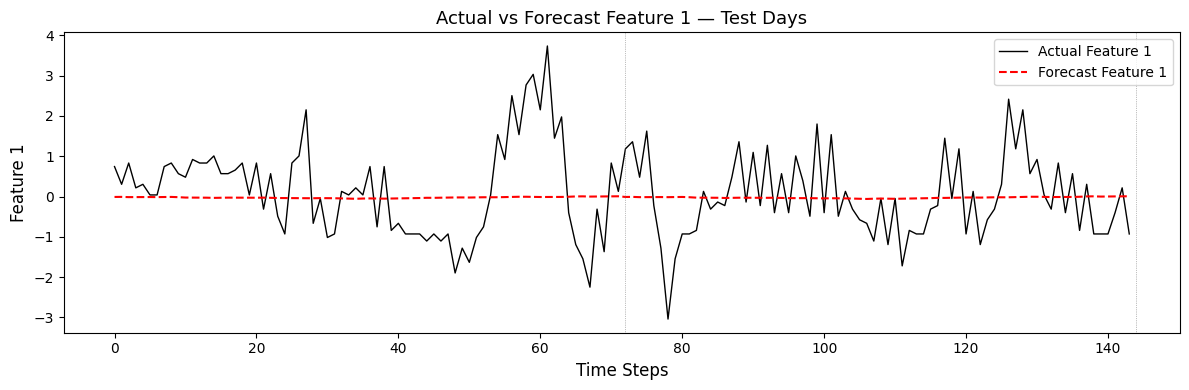

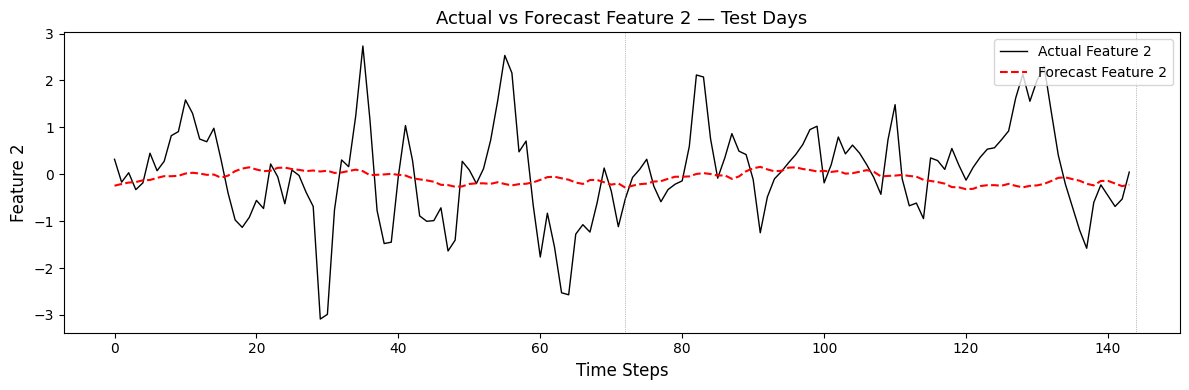

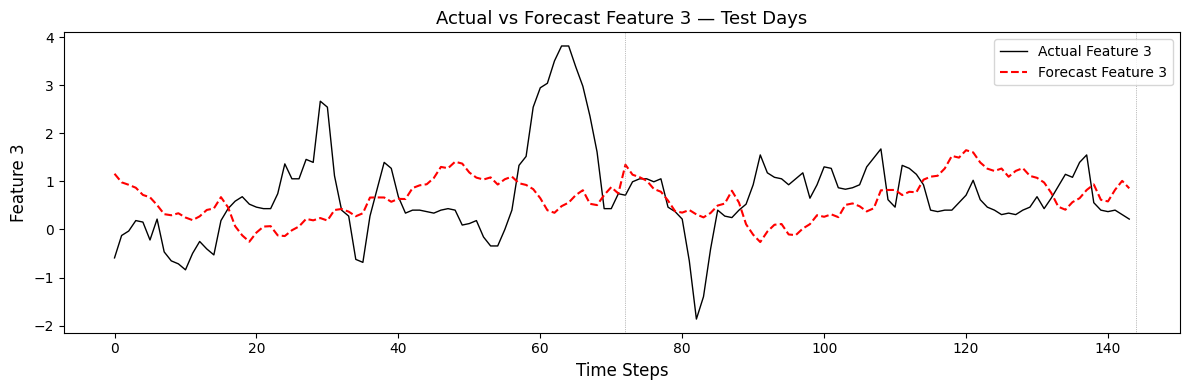

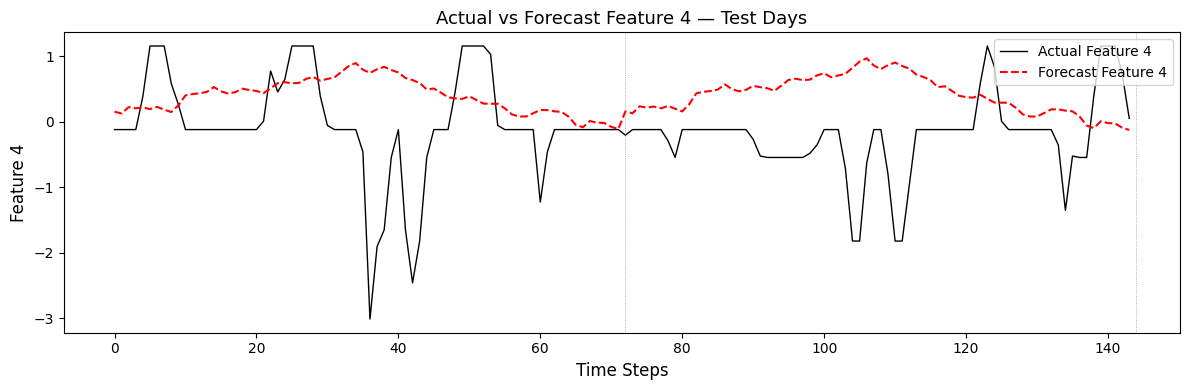

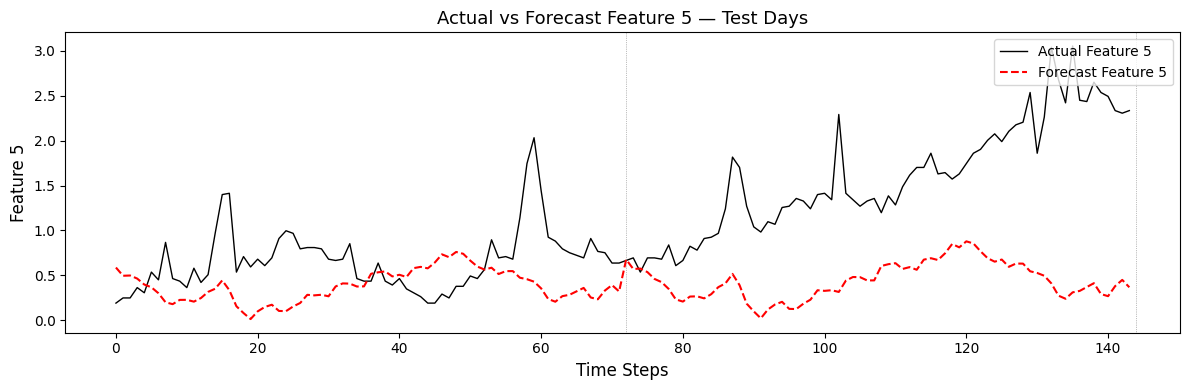

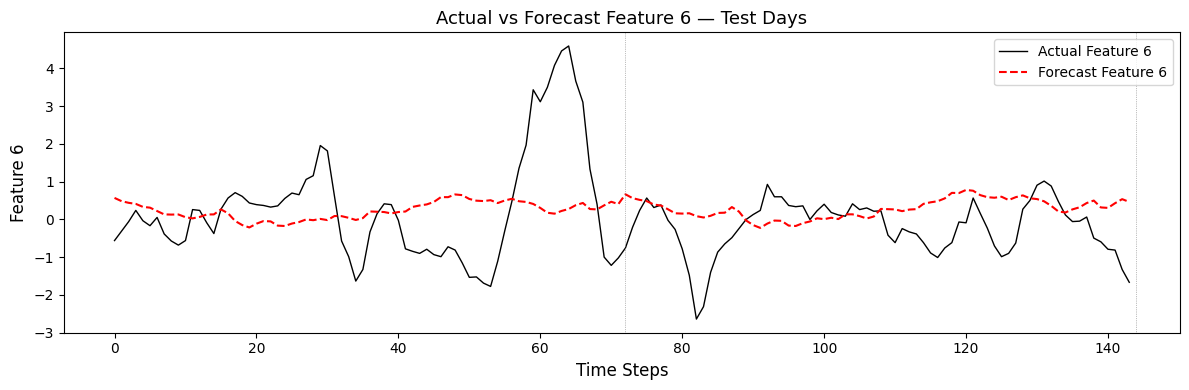

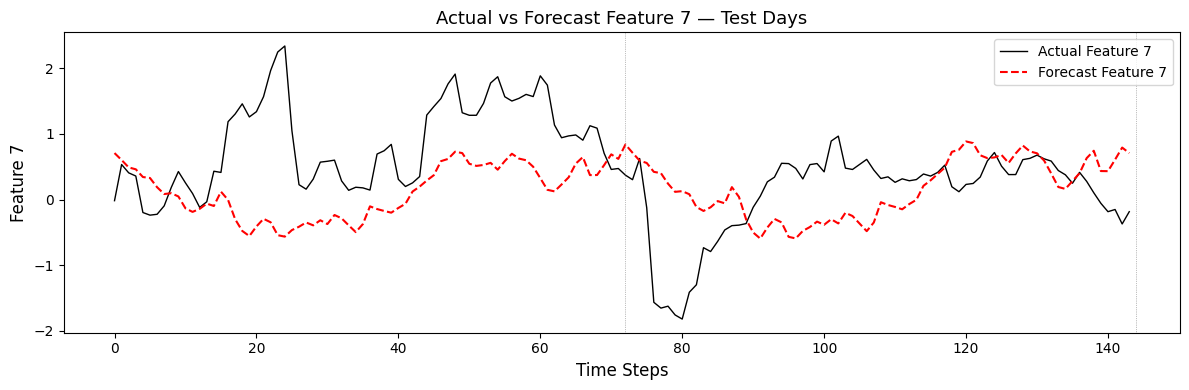

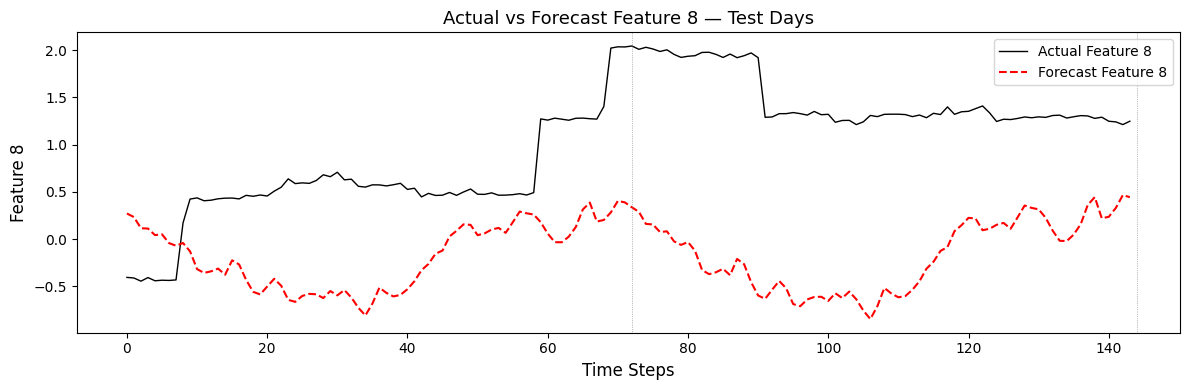

In [244]:
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)
forecast_series = forecast_tensor.reshape(-1, FEATURES)
x = np.arange(TEST_DAYS * TIME)

for i in range(FEATURES):
    plt.figure(figsize=(12, 4))
    plt.plot(test_series[:, i], 'k-', lw=1, label=f'Actual Feature {i}')
    plt.plot(forecast_series[:, i], 'r--', lw=1.5, label=f'Forecast Feature {i}')
    for d in range(1, TEST_DAYS + 1):
        plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    plt.title(f'Actual vs Forecast Feature {i} — Test Days', fontsize=13)
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel(f'Feature {i}', fontsize=12)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

In [245]:
train_series = tensor[:TRAIN_DAYS].reshape(-1, FEATURES)
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)

train_series.shape, test_series.shape

((360, 9), (144, 9))

In [246]:
# Accuracy calculation using R squared (R²) metric
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

r2_scores = []
mse_scores = []
mae_scores = []
rmse_scores = []

for i in range(FEATURES):
    r2 = r2_score(test_series[:, i], forecast_series[:, i])
    mse = mean_squared_error(test_series[:, i], forecast_series[:, i])
    mae = mean_absolute_error(test_series[:, i], forecast_series[:, i])
    rmse = root_mean_squared_error(test_series[:, i], forecast_series[:, i])
    r2_scores.append(r2)
    mse_scores.append(mse)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    print(f"Feature {i} R²: {r2:.4f}, MSE: {mse:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}")

print("average R²: {:.4f}, average MSE: {:.4f}, average MAE: {:.4f}, average RMSE: {:.4f}".format(
    np.mean(r2_scores), np.mean(mse_scores), np.mean(mae_scores), np.mean(rmse_scores)))

Feature 0 R²: -3.0575, MSE: 0.8732, MAE: 0.7301, RMSE: 0.9344
Feature 1 R²: -0.0049, MSE: 1.1983, MAE: 0.8636, RMSE: 1.0947
Feature 2 R²: -0.0409, MSE: 1.0812, MAE: 0.7849, RMSE: 1.0398
Feature 3 R²: -0.3305, MSE: 1.1114, MAE: 0.8376, RMSE: 1.0542
Feature 4 R²: -0.9663, MSE: 1.0232, MAE: 0.7645, RMSE: 1.0115
Feature 5 R²: -1.0889, MSE: 0.9874, MAE: 0.7828, RMSE: 0.9937
Feature 6 R²: -0.1446, MSE: 1.6306, MAE: 0.9529, RMSE: 1.2770
Feature 7 R²: -0.4446, MSE: 0.8499, MAE: 0.7244, RMSE: 0.9219
Feature 8 R²: -3.9317, MSE: 1.9025, MAE: 1.2529, RMSE: 1.3793
average R²: -1.1122, average MSE: 1.1842, average MAE: 0.8549, average RMSE: 1.0785
